# Overview

This notebook is for the purpose of analyzing the results from run.py when we run and collect raw trajectories, without any memories. This data is then used to create memories. This notebook contains code to also get (environment cue, LLM reasoning, action) tuples for each collected trajectory, for later storing in QDrant DB.

In [7]:
import pandas as pd
import csv
import os, pickle
from pathlib import Path

There are multiple runs across 2 LLMs - `together_ai/Qwen/Qwen3-Next-80B-A3B-Instruct` and `together_ai/OpenAI/gpt-oss-120B`. Let's create a single dataframe with the run results, concatenated across all

In [2]:
def clean_csv(p):
    cleaned_rows = []

    with open(p, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = ["task_id", "task", "success", "steps"]
        cleaned_rows.append(header)

        for row in reader:
            # If the row doesn't have exactly 3 columns, reconstruct from last two
            if len(row) != 3:
                success = row[-2]
                steps = row[-1]
                combined = ",".join(row[:-2])     # contains: task_id + task
            else:
                combined, success, steps = row

            # Split task_id from task (only split on first comma)
            if "," in combined:
                task_id, task = combined.split(",", 1)
            else:
                # fallback: no comma found (should not happen)
                task_id = combined
                task = ""

            # Escape internal quotes per CSV rules
            task = task.replace('"', '""')

            cleaned_rows.append([task_id, task, success, steps])

    # Write cleaned CSV
    out_path = p.replace(".csv", "_cleaned.csv")
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f, quoting=csv.QUOTE_ALL)
        writer.writerows(cleaned_rows)


In [23]:
clean_csv('/Users/deanorenstein/Documents/academic/self improving AI agents/project/ARMPA/webarena/runs/20251118161129_qwen_full/results_first_corrected.csv')

In [43]:
# Collect mapping of task_id (pickle file name) to task (column in CSV)
# So we dont rely on unreliable mapping between CSV row and position of pickle in directory
import json
task_id_to_task = {}

st_idx = 0
ed_idx = 200 # However many webarena tasks we will use
test_file_list = []
for i in range(st_idx, ed_idx):
    test_file_list.append(f"config_files/{i}.json")

for config_file in test_file_list:
    with open(config_file) as f:
        _c = json.load(f)
        intent = _c["intent"]
        task_id = _c["task_id"]

        task_id_to_task[task_id] = intent

In [30]:
cleaned_paths = ["runs/20251117213558_gpt_full/results_cleaned.csv", "runs/20251118091613_gpt_full_2/results_cleaned.csv", "runs/20251118161129_qwen_full/results_cleaned.csv"]
df1 = pd.read_csv(cleaned_paths[0])
df2 = pd.read_csv(cleaned_paths[1])
df3 = pd.read_csv(cleaned_paths[2])

# Add LLM column to each dataframe
df1['llm'] = 'GPT-OSS-120B'
df2['llm'] = 'GPT-OSS-120B'
df3['llm'] = 'Qwen-80B'

df1['run_path'] = 'runs/20251117213558_gpt_full'
df2['run_path'] = 'runs/20251118091613_gpt_full_2'
df3['run_path'] = 'runs/20251118161129_qwen_full'

combined = pd.concat([df1, df2, df3], ignore_index=True)

In [33]:
combined = combined[combined['task_id'] != 'task_id']
combined['task'] = combined['task'].str.replace('""', '"')

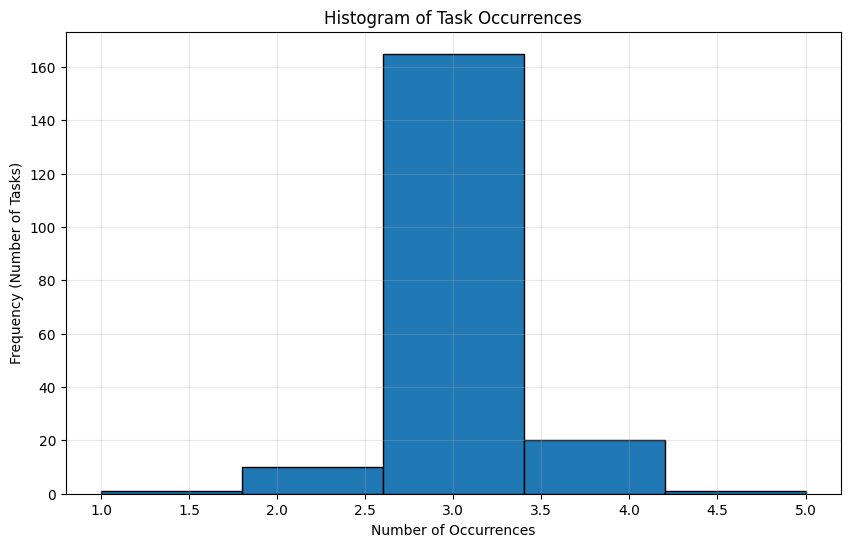

In [42]:
task_counts = combined['task'].value_counts()
# Create histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(task_counts.values, bins=5, edgecolor='black')
plt.xlabel('Number of Occurrences')
plt.ylabel('Frequency (Number of Tasks)')
plt.title('Histogram of Task Occurrences')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Normalize task_id
def normalize(task_id):
    return task_id_to_task[int(task_id)]

combined['task'] = combined['task_id'].apply(normalize)


In [43]:
# save to csv
combined.to_csv('runs/df_combined.csv', index=False)

In [11]:
# read csv
combined = pd.read_csv('runs/trajectory_steps_success.csv')

Note down what trajectories succeeded, and which ones succeeded for 1 LLM but not another

In [48]:
common_tasks = set(unique_df_gpt['task']).intersection(set(unique_df_qwen['task']))
len(common_tasks)

81

In [50]:
# Filter both DFs to only successful tasks
df_gpt_success = unique_df_gpt[unique_df_gpt['success'] == 1]
df_qwen_success = unique_df_qwen[unique_df_qwen['success'] == 1]

# Find common tasks that succeeded in BOTH dataframes
common_success_tasks = set(df1_success['task']).intersection(set(df2_success['task']))

### Viewing LLM reasoning stats

In [52]:
paths = ["runs/20251117213558_gpt_full/trajectories", "runs/20251118091613_gpt_full_2/trajectories", "runs/20251118161129_qwen_full/trajectories"]

In [78]:
import os, pickle
def show_percentage_empty_llm_reasoning(path):
    empty_reasoning_count = 0
    total_actions = 0
    for x in os.listdir(path):
        if x.endswith(".pkl"):
            traj = pickle.load(open(f"{path}/{x}", "rb"))
            for i in range(1, len(traj), 2):
                total_actions += 1
                if traj[i].get('llm_reasoning') == '':
                    empty_reasoning_count += 1
                    print(traj[i].get('answer'))
    return empty_reasoning_count / total_actions


In [79]:
show_percentage_empty_llm_reasoning(paths[1])

ERROR: Cannot parse action from response: The **HEIYING Game Card Case for Nintendo Switch & Switch OLED** is the best choice. It provides **24 game‑card slots** (and 24 micro‑SD slots), far more than the 6 cards you have, and it has a high rating of **97 %** with multiple reviews. At **$14.69**, it’s a reasonably priced, highly‑rated option that will comfortably hold all of your cards now and give you plenty of room for future additions.
Early stop: Failed to parse actions for 3 times
Early stop: Same typing action for 3 times
Early stop: Failed to parse actions for 3 times
Early stop: Reach max steps 30
ERROR: Cannot parse action from response: 
Early stop: Failed to parse actions for 3 times
ERROR: Cannot parse action from response: We need to continue filling other fields.Next zip.

Now select country. We'll click combobox then type.

Now type United States.

Now state.

Now type Illinois.

Now save.

The address information has been updated successfully.
Early stop: Same typing ac

0.06227106227106227

In [80]:
show_percentage_empty_llm_reasoning(paths[2])

Early stop: Same typing action for 3 times
Early stop: Same action for 3 times
Early stop: Reach max steps 30
Early stop: Same typing action for 3 times
Early stop: Reach max steps 30
Early stop: Same typing action for 3 times
Early stop: Failed to parse actions for 3 times
Early stop: Same typing action for 3 times
Early stop: Reach max steps 30
Early stop: Same action for 3 times
Early stop: Reach max steps 30
Early stop: Failed to parse actions for 3 times
Early stop: Same typing action for 3 times
Early stop: Reach max steps 30
Early stop: Reach max steps 30
Early stop: Reach max steps 30
Early stop: Same typing action for 3 times
Early stop: Same typing action for 3 times
Early stop: Failed to parse actions for 3 times
Early stop: Same typing action for 3 times
Early stop: Same typing action for 3 times
Early stop: Same typing action for 3 times
Early stop: Same typing action for 3 times
Early stop: Same action for 3 times
Early stop: Same action for 3 times
Early stop: Same typin

0.03875968992248062

## Storing into QDrant

Lets now store the summarized trajectories into QDrant. This is 1 form of memory our recall agent will consider.

We will have different collection names for different kinds of memory.

In [2]:
from dotenv import load_dotenv
# input path to .env file, which should contain TOGETHER_API_KEY
load_dotenv(override=True)

%load_ext autoreload
%autoreload 2

from tqdm import tqdm
import sys
sys.path.append('../')

from webarena.browser_env.helper_functions import get_action_description
from webarena.agent.prompts import PromptConstructor
from memory.manager import MemoryManager

/Users/deanorenstein/Documents/academic/self improving AI agents/project/ARMPA/.venv/lib/python3.10/site-packages/beartype/_util/hint/pep/utilpeptest.py:345: BeartypeDecorHintPep585DeprecationWarning: PEP 484 type hint typing.Mapping[str, gymnasium.spaces.space.Space[typing.Any]] deprecated by PEP 585 scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". See this discussion for further details and alternatives:
    https://github.com/beartype/beartype#pep-585-deprecations
  warn(
/Users/deanorenstein/Documents/academic/self improving AI agents/project/ARMPA/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/deanorenstein/Documents/academic/self improving AI agents/project/ARMPA/.venv/li

### Storing historical trajectories (from all runs)

This is so that our RL can compute reward against the historical best

In [162]:
MEMORY_COLLECTION_NAME = "webarena"
memory_manager = MemoryManager(collection_name=MEMORY_COLLECTION_NAME)

Collection 'webarena-cues' already exists, using existing collection.
Collection 'webarena-trajectory-history' already exists, using existing collection.
Collection 'webarena-reasoningbank' already exists with single vector (backward compatible).
✅ Created payload index on 'goal' field for collection 'webarena-cues'
✅ Created payload index on 'goal' field for collection 'webarena-trajectory-history'
✅ Created payload index on 'success' field for collection 'webarena-trajectory-history'
✅ Created payload index on 'goal' field for collection 'webarena-reasoningbank'
✅ Created payload index on 'success' field for collection 'webarena-reasoningbank'


In [14]:
memory_manager.reset_collection('webarena-trajectory-history')
memory_manager.reset_collection('webarena-cues')

🗑️  Deleted collection 'webarena-trajectory-history'
✅ Recreated empty collection 'webarena-trajectory-history'
✅ Created payload index on 'goal' field for collection 'webarena-trajectory-history'
✅ Created payload index on 'success' field for collection 'webarena-trajectory-history'
🗑️  Deleted collection 'webarena-cues'
✅ Recreated empty collection 'webarena-cues'
✅ Created payload index on 'goal' field for collection 'webarena-cues'


In [195]:
memory_manager.reset_collection('webarena-reasoningbank')

🗑️  Deleted collection 'webarena-reasoningbank'
Created reasoningbank collection 'webarena-reasoningbank' with named vectors (goal, content).
✅ Recreated empty collection 'webarena-reasoningbank'
✅ Created payload index on 'goal' field for collection 'webarena-reasoningbank'
✅ Created payload index on 'success' field for collection 'webarena-reasoningbank'


In [9]:
memory_manager.print_all_memories(collection='webarena-cues')


🎯 Unique goals (count: 0): set()
📭 No memories found in the collection 'webarena-cues'.


In [15]:
for _, r in tqdm(combined.iterrows()):
    success = int(r['success']) == 1
    steps = int(r['steps'])
    path = r['run_path']
    memory_manager.store_trajectory_history(goal=r['task'], num_steps=steps, success=success)

601it [00:59, 10.05it/s]


In [87]:
# sample a random 5 goals
samp_tasks = combined.sample(5)['task'].values
# make it the entire row
samp = combined[combined['task'].isin(samp_tasks)]

In [ ]:
for _, row in samp.iterrows():
    print(row['task'])
    print(f"Steps + success here: {row['steps']}, {row['success']}")
    print(memory_manager.get_best_trajectory_sample(goal=row['task'], require_success=True))
    print("-"*100)

### Summarizing trajectories and storing cues

In [16]:
from webarena.agent.agent import PromptAgent
agent = PromptAgent(
    action_set_tag="id_accessibility_tree",
    model="together_ai/OpenAI/gpt-oss-120B",
    temperature=0.7,
    use_litellm=True,
    instruction_path="agent/prompts/raw/p_direct_id_actree_2s_no_na.py",
    verbose=False # set to True if we want to see the full prompt and agent response under the hood each time
)

First, summarize (we assume we did run.py without any summarizing)

In [63]:
def summarize_trajectory(trajectory: list, model: str = "together_ai/OpenAI/gpt-oss-120B", temperature: float = 0.0):
    observations_actions_reasonings = []

    for i in tqdm(
        range(0, len(trajectory) - 1, 2),
        desc="Steps",
        position=1,
        leave=False,
    ):
        observation_item = trajectory[i]
        next_action_item = trajectory[i + 1]

        # Summarize the current observation (cue)
        summarized_obs = memory_manager.summarize_webarena_observation(
            observation_item["observation"]["text"],
            model=model,
            temperature=0.0,
            max_tokens=300
        )

        # Describe the next action taken after this observation
        next_action_text = get_action_description(
            next_action_item, observation_item["info"]["observation_metadata"],
            action_set_tag="id_accessibility_tree",
            prompt_constructor=agent.prompt_constructor
        )

        observations_actions_reasonings.append((summarized_obs, next_action_text, next_action_item.get('llm_reasoning')))

    return observations_actions_reasonings


In [ ]:
def get_summarized_trajectories(run_path: str):
    # Create the output directory if it doesn't exist
    output_dir = Path(run_path) / "summarized_trajectories"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    pkls = os.listdir(f"{run_path}/trajectories/")
    print(f"Summarizing {len(pkls)} trajectories from {run_path}...")
    for pkl in tqdm(pkls, desc="Trajectories", position=0):
        traj = pickle.load(open(f"{run_path}/trajectories/{pkl}", "rb"))
        # if summarized_trajectories/pkl exists, skip
        if os.path.exists(f"{run_path}/summarized_trajectories/{pkl}"):
            continue
        oar = summarize_trajectory(traj, model="together_ai/meta-llama/Llama-3.3-70B-Instruct-Turbo", temperature=0.0)
        # Store the pickle
        pickle.dump(oar, open(f"{run_path}/summarized_trajectories/{pkl}", "wb"))

In [ ]:
get_summarized_trajectories("runs/20251117213558_gpt_full")

In [65]:
get_summarized_trajectories("runs/20251117213558_gpt_full")


Summarizing 197 trajectories from runs/20251117213558_gpt_full...


Trajectories: 100%|██████████| 197/197 [2:29:10<00:00, 45.43s/it]   


In [68]:
get_summarized_trajectories("runs/20251118091613_gpt_full_2")

Summarizing 191 trajectories from runs/20251118091613_gpt_full_2...


Trajectories: 100%|██████████| 191/191 [2:42:08<00:00, 50.93s/it]   


In [69]:
get_summarized_trajectories("runs/20251118161129_qwen_full")

Summarizing 195 trajectories from runs/20251118161129_qwen_full...


Trajectories: 100%|██████████| 195/195 [2:37:21<00:00, 48.42s/it]  


Now, we can store them

In [ ]:
def store_summarized_trajectories_from_run(run_path: str):
    # Load the results csv
    df_results = pd.read_csv(f"{run_path}/results_cleaned.csv")
    df_results['task'] = df_results['task'].str.replace('""', '"')
    pickle_files = os.listdir(f"{run_path}/summarized_trajectories/")
    
    for pickle_file in tqdm(pickle_files):
        
        observations_actions_reasonings = pickle.load(open(f"{run_path}/summarized_trajectories/{pickle_file}", "rb"))

        task_id = int(pickle_file.replace(".pkl", ""))
        task = task_id_to_task[task_id]
        
        row = df_results[df_results['task_id'] == task_id].values
        if len(row) == 0:
            continue

        row = row[0]

        goal, success = row[0], row[1]

        memory_manager.store_trajectory(
            observations_actions_reasonings=observations_actions_reasonings,
            goal=goal,
            success=success == 1,
        )

In [ ]:
# Load the summarized trajectories...
remaining_paths = ["runs/20251118161129_qwen_full"]

for p in remaining_paths:
    store_summarized_trajectories_from_run(p)

## Getting several sample memories by looking up based on goal/task

To be used to test RL training

In [174]:
df1[df1['success'] == 1].sample(1).values[0][0]

'Add Tide PODS Spring Meadow Scent HE Turbo Laundry Detergent Pacs, 81 Count to my wish list'

In [154]:
df1[df1['success'] == 0].sample(1).values[0][0]

'How many commits did Nic make in April 2021?'

In [175]:
g1 = 'Add Tide PODS Spring Meadow Scent HE Turbo Laundry Detergent Pacs, 81 Count to my wish list'
g2 = 'How many commits did Nic make in April 2021?'

In [186]:
def print_cue_mems_for_goal(goal: str):
    mems = memory_manager.get_memories_by_goal(goal)

    formatted_mems = []
    for m in mems:
        # If there is an 'obs_summary' field, then we know it's a cue-action mapping
        if 'obs_summary' in m:
            success = "success" if m['success'] else "failure"
            pointer = "(DONT DO AGAIN)" if not m['success'] else ""
            formatted_mems.append(f"""Last time I was in a similar situation, I tried doing the corresponding action, and it ultimately led to {success}:

WHAT I SAW:
{m['obs_summary']}

WHAT I DID{pointer}:
{m['action_taken']}
""")

    print(f"MEMORIES FOR GOAL: {goal} (SUCCESS = {success})\n")
    for mem in formatted_mems:
        print(mem)
        print("--------------------------------")

In [ ]:
print_cue_mems_for_goal(g1)

In [ ]:
print_cue_mems_for_goal(g2)

## ReasoningBank

Purpose of this section is to explore and apply [ReasoningBank](https://arxiv.org/pdf/2509.25140)-style memories to our webarena trajectories. In addition to generalized, LLM-supplied, trajectory-level lessons from both successes and failures, can we adapt the ReasoningBank prompts to also give us learnings/lessons/skills that pertain to certain STEPS of a trajectory?

In [ ]:
from memory.prompts.lessons import success_prompt, failure_prompt
from webarena.llms.providers.litellm_utils import generate_from_litellm_completion

In [55]:
def get_formatted_trajectory_for_prompt(observations_actions_reasonings: list) -> str:
    """ The ReasoningBank paper constructs a trajectory (for trajectory lesson discovery)
    by considering the per-step agent actions, its reasoning behind them,
    and the resulting (i+1) observation (summarized).
    """

    # ---- Step 0 values ----
    initial_obs = observations_actions_reasonings[0][0].strip()
    initial_action = observations_actions_reasonings[0][1].replace('\n', '').strip()
    initial_reasoning = observations_actions_reasonings[0][2].replace('\n', '').strip()

    formatted_traj = (
        f"\nINITIAL OBSERVATION:\n{initial_obs}\n"
        f"ACTION:\n{initial_action}\n"
        f"REASONING:\n{initial_reasoning}\n"
    )

    # ---- Remaining steps ----
    for i in range(1, len(observations_actions_reasonings)):
        obs_i = observations_actions_reasonings[i][0].strip()
        action_i = observations_actions_reasonings[i][1].replace('\n', '').strip()
        reasoning_i = (
            observations_actions_reasonings[i][2].replace('\n', '').strip()
            if observations_actions_reasonings[i][2]
            else None
        )

        formatted_traj += f"OUTCOME:\n{obs_i}\n\n"
        formatted_traj += f"ACTION:\n{action_i}\n"

        if reasoning_i:
            formatted_traj += f"REASONING:\n{reasoning_i}\n"

    formatted_traj += "<END OF TRAJECTORY>"

    return formatted_traj


In [174]:
def store_reasoningbank_memories_from_run(run_path: str):
    # Load the results csv
    df_results = pd.read_csv(f"{run_path}/results_cleaned.csv")
    df_results['task'] = df_results['task'].str.replace('""', '"')
    pickle_files = os.listdir(f"{run_path}/summarized_trajectories/")
    
    for pickle_file in tqdm(pickle_files):
        observations_actions_reasonings = pickle.load(open(f"{run_path}/summarized_trajectories/{pickle_file}", "rb"))
        formatted_traj = get_formatted_trajectory_for_prompt(observations_actions_reasonings)

        task_id = int(pickle_file.replace(".pkl", ""))
        task = task_id_to_task[task_id]

        user_prompt = f"""
QUERY: {task}
TRAJECTORY:
{formatted_traj}
        """
        
        row = df_results[df_results['task_id'] == task_id].values
        if len(row) == 0:
            continue

        row = row[0]
        goal, success = row[1], row[2]

        success = int(success) == 1
        prompt = ""
        if success:
            prompt = success_prompt
        else:
            prompt = failure_prompt

        try:
            response = generate_from_litellm_completion(
                prompt=prompt,
                model="together_ai/OpenAI/gpt-oss-120B",
                temperature=1.0, # Same temperature as the original paper for memory extraction
                max_tokens=1024,
                system_prompt=user_prompt,
                stop_sequences=None,
            )
            mem_items = json.loads(response['answer'])
            mem_items = mem_items['memory_items']

            memory_manager.store_reasoningbank_memories(
                memory_items=mem_items,
                goal=task,
                success=success,
                source_trajectory_id=task_id
            )
        except Exception as e:
            failed_prompts.append(x)
            print(f"failed {len(failed_prompts)} times on task ID {task_id} - {e}")

In [ ]:
store_reasoningbank_memories_from_run("runs/20251117213558_gpt_full")

In [ ]:
store_reasoningbank_memories_from_run("runs/20251118091613_gpt_full_2")

In [ ]:
store_reasoningbank_memories_from_run("runs/20251118161129_qwen_full")

In [ ]:
memory_manager.retrieve_reasoningbank_memories("Thumbs down the top 5 post ever in technology.")

9

## Formatting all memories for a given goal

We can retrieve particular cue-based memories, and ReasoningBank memories, on a given task, by searching against that task.

For cue-based:
- If a retrieved cue involved an action that led to success, then take all such success actions.
- If no retrieved cues have actions affiliated with success, then include all cue memories.
- Format these accordingly (WHEN I WAS IN A SIMILAR SITUTATION, I TRIED X, and IT ULTIMATELY LED TO Y)

For ReasoningBank memories:
- We retrieve all 9 or so ReasoningBank-style memories (title, description, content), and take the content.
- Format these accordingly (LESSONS LEARNED FROM THE PAST: *all contents*)

In [196]:
goal = "Find a subreddit focused on topics related to NYC, and post my question, \"is car necessary\" there"
# load gpt 2
pkl = "runs/20251118091613_gpt_full_2/trajectories/606.pkl"
traj = pickle.load(open(pkl, "rb"))

In [197]:
ex_observation = traj[4]['observation']['text']

In [205]:
cue_mems = memory_manager.cue_based_recall(ex_observation, goal, top_k=15)

In [200]:
cue_success_mems = [m for m in cue_mems if m['success']]

In [201]:
len(cue_success_mems)

0

In [206]:
len(cue_mems)

15

In [ ]:
cue_mems[0].get('embedding')

In [161]:
rb_mems[0].keys()

dict_keys(['score', 'memory_id', 'title', 'description', 'content', 'goal', 'success', 'created_at', 'source_trajectory_id'])

In [202]:
rb_mems = memory_manager.retrieve_reasoningbank_memories(goal, search_by="goal")

In [204]:
len(rb_mems)

6

In [ ]:
rb_mems[0].get('embedding') or rb_mems[0].get('embeddings')['content']

In [207]:
rb_mems[0]['content_embedding'] = rb_mems[0].get('embeddings')['content']

In [ ]:
for x in memory_manager.get_formatted_memories_for_prompt(rb_mems + cue_success_mems):
    print(x)

In [ ]:
memory_manager.update_reasoningbank_with_content_embeddings()